In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Les bibliotheques :

In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Flatten, Input, Dropout
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

Architectur du CNN:

In [3]:
import torch
import torch.nn as nn

class CNNSubModule(nn.Module):
    """
    CNN sub-module du CTFusion stage (MCTNet).
    ResBlock 1D : 2x Conv1D + BN + connexion résiduelle + ReLU.
    Input/Output : (B, C, T)
    B = Batch size     → combien de pixels on traite en même temps
    C = Channels       → combien de bandes / canaux d'information
    T = Timesteps      → combien de semaines dans la série temporelle
    """
    def __init__(self, in_channels: int):
        super().__init__()
        self.conv1 = nn.Conv1d(
            in_channels,   # canaux en ENTRÉE  → ex: 10
            in_channels,   # canaux en SORTIE  → ex: 10  (même valeur !)
            kernel_size=3, # taille de la loupe → regarde 3 timesteps à la fois
            padding=1,     # ajoute 1 case vide de chaque côté → garde T intact
            bias=False     # pas de biais → inutile car BatchNorm suit juste après
        )
        self.bn1 = nn.BatchNorm1d(in_channels) #il doit correspondre à ce qui sort de la conv juste avant

        self.conv2 = nn.Conv1d(
            in_channels, in_channels,
            kernel_size=3, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm1d(in_channels)

        self.relu = nn.ReLU(inplace=True) # inplace=True : modifie les données en place → économise de la mémoire

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x : (B, C, T)
        residual = x

        out = self.conv1(x)       # (B, C, T)
        out = self.bn1(out)

        out = self.conv2(out)     # (B, C, T)
        out = self.bn2(out)

        out = self.relu(out + residual)   # connexion résiduelle
        return out

 Créer le modèle pour le Stage 1

**Les données réelles:**

Arkansas_10k.csv et California_10k.csv. Chaque ligne = 1 pixel. Le format attendu au final :

CSV  →  (N pixels, 360 colonnes + 1 label)
         └── 10 bandes × 36 semaines = 360 valeurs par pixel

In [4]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

# --- Charger les fichiers .npy ---
X_train = np.load('/content/drive/MyDrive/Sentinel2_Project/data_set/20m/preprocessed/California_train_input1.npy')   # ex: (1200, 10, 36)
X_val   = np.load('/content/drive/MyDrive/Sentinel2_Project/data_set/20m/preprocessed/California_val_input1.npy')     # ex: (300, 10, 36)
X_test  = np.load('/content/drive/MyDrive/Sentinel2_Project/data_set/20m/preprocessed/California_test_input1.npy')    # ex: (8500, 10, 36)

# Les labels — même nom mais avec "labels" ou "y"
# adapte le nom selon ce que Sarah a produit

y_train = np.load('/content/drive/MyDrive/Sentinel2_Project/data_set/20m/preprocessed/California_train_labels.npy')   # ex: (1200, 10, 36)
y_val   = np.load('/content/drive/MyDrive/Sentinel2_Project/data_set/20m/preprocessed/California_val_labels.npy')     # ex: (300, 10, 36)
y_test  = np.load('/content/drive/MyDrive/Sentinel2_Project/data_set/20m/preprocessed/California_test_labels.npy')    # ex: (8500, 10, 36)



# --- Vérifier les shapes ---
print("X_train :", X_train.shape)   # doit être (N, 10, 36)
print("y_train :", y_train.shape)   # doit être (N,)

print("X_val :", X_val.shape)
print("y_val :", y_val.shape)

print("X_test :", X_test.shape)   # doit être (N, 10, 36)
print("y_test :", y_test.shape)   # doit être (N,)

print("Classes :", np.unique(y_train))

X_train : (1440, 36, 10)
y_train : (1440,)
X_val : (360, 36, 10)
y_val : (360,)
X_test : (8200, 36, 10)
y_test : (8200,)
Classes : [0 1 2 3 4 5]


# Correction du shape : (B, T, C) → (B, C, T)



In [5]:
# Correction du shape : (B, T, C) → (B, C, T)
X_train = X_train.transpose(0, 2, 1)   # (8200, 36, 10) → (8200, 10, 36)
X_val   = X_val.transpose(0, 2, 1)     # (360,  36, 10) → (360,  10, 36)
X_test  = X_test.transpose(0, 2, 1)    # (1440, 36, 10) → (1440, 10, 36)

# Vérification
print("X_train :", X_train.shape)   # (8200, 10, 36) ✅
print("X_val   :", X_val.shape)     # (360,  10, 36) ✅
print("X_test  :", X_test.shape)    # (1440, 10, 36) ✅

X_train : (1440, 10, 36)
X_val   : (360, 10, 36)
X_test  : (8200, 10, 36)


In [9]:

# 3. CONVERTIR EN TENSEURS
# ============================================================
X_train = torch.from_numpy(X_train).float()
X_val   = torch.from_numpy(X_val).float()
X_test  = torch.from_numpy(X_test).float()
y_train = torch.from_numpy(y_train).long()
y_val   = torch.from_numpy(y_val).long()
y_test  = torch.from_numpy(y_test).long()

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val,   y_val),   batch_size=32, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=32, shuffle=False)

# ============================================================
# 4. MODÈLE
# ============================================================
class CNNSubModule(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, in_channels, kernel_size=3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm1d(in_channels)
        self.conv2 = nn.Conv1d(in_channels, in_channels, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm1d(in_channels)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x
        out = self.bn1(self.conv1(x))
        out = self.bn2(self.conv2(out))
        return self.relu(out + residual)


class CNNClassifier(nn.Module):
    def __init__(self, in_channels, n_classes):
        super().__init__()
        self.cnn  = CNNSubModule(in_channels)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc   = nn.Linear(in_channels, n_classes)

    def forward(self, x):
        out = self.cnn(x)        # (B, 10, 36)
        out = self.pool(out)     # (B, 10, 1)
        out = out.squeeze(-1)    # (B, 10)
        return self.fc(out)      # (B, 6)


N_CLASSES = len(torch.unique(y_train))
model     = CNNClassifier(in_channels=10, n_classes=N_CLASSES)
print(f"Classes    : {N_CLASSES}")
print(f"Paramètres : {sum(p.numel() for p in model.parameters())}")

# ============================================================
# 5. ENTRAÎNEMENT
# ============================================================
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn   = nn.CrossEntropyLoss()
EPOCHS    = 200

history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

for epoch in range(EPOCHS):

    model.train()
    train_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = loss_fn(out, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        correct    += (out.argmax(1) == y_batch).sum().item()
        total      += len(y_batch)

    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            out          = model(X_batch)
            val_loss    += loss_fn(out, y_batch).item()
            val_correct += (out.argmax(1) == y_batch).sum().item()
            val_total   += len(y_batch)

    history['loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss / len(val_loader))
    history['accuracy'].append(correct / total)
    history['val_accuracy'].append(val_correct / val_total)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Loss: {history['loss'][-1]:.4f} | "
              f"Acc: {history['accuracy'][-1]:.4f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f} | "
              f"Val Acc: {history['val_accuracy'][-1]:.4f}")



Classes    : 6
Paramètres : 706
Epoch   0/200 | Loss: 2.2575 | Acc: 0.2368 | Val Loss: 1.7085 | Val Acc: 0.2750
Epoch  10/200 | Loss: 0.8814 | Acc: 0.7326 | Val Loss: 0.8784 | Val Acc: 0.7556
Epoch  20/200 | Loss: 0.6219 | Acc: 0.8333 | Val Loss: 0.6144 | Val Acc: 0.8111
Epoch  30/200 | Loss: 0.4737 | Acc: 0.8535 | Val Loss: 0.4740 | Val Acc: 0.8639
Epoch  40/200 | Loss: 0.3925 | Acc: 0.8833 | Val Loss: 0.4043 | Val Acc: 0.8722
Epoch  50/200 | Loss: 0.3377 | Acc: 0.8944 | Val Loss: 0.3784 | Val Acc: 0.8778
Epoch  60/200 | Loss: 0.2916 | Acc: 0.9111 | Val Loss: 0.3858 | Val Acc: 0.8722
Epoch  70/200 | Loss: 0.2724 | Acc: 0.9187 | Val Loss: 0.3950 | Val Acc: 0.8694
Epoch  80/200 | Loss: 0.2551 | Acc: 0.9194 | Val Loss: 0.3301 | Val Acc: 0.8889
Epoch  90/200 | Loss: 0.2326 | Acc: 0.9271 | Val Loss: 0.3279 | Val Acc: 0.9111
Epoch 100/200 | Loss: 0.2230 | Acc: 0.9264 | Val Loss: 0.4052 | Val Acc: 0.8556
Epoch 110/200 | Loss: 0.2291 | Acc: 0.9271 | Val Loss: 0.3903 | Val Acc: 0.8778
Epoch 12

#Resultats :

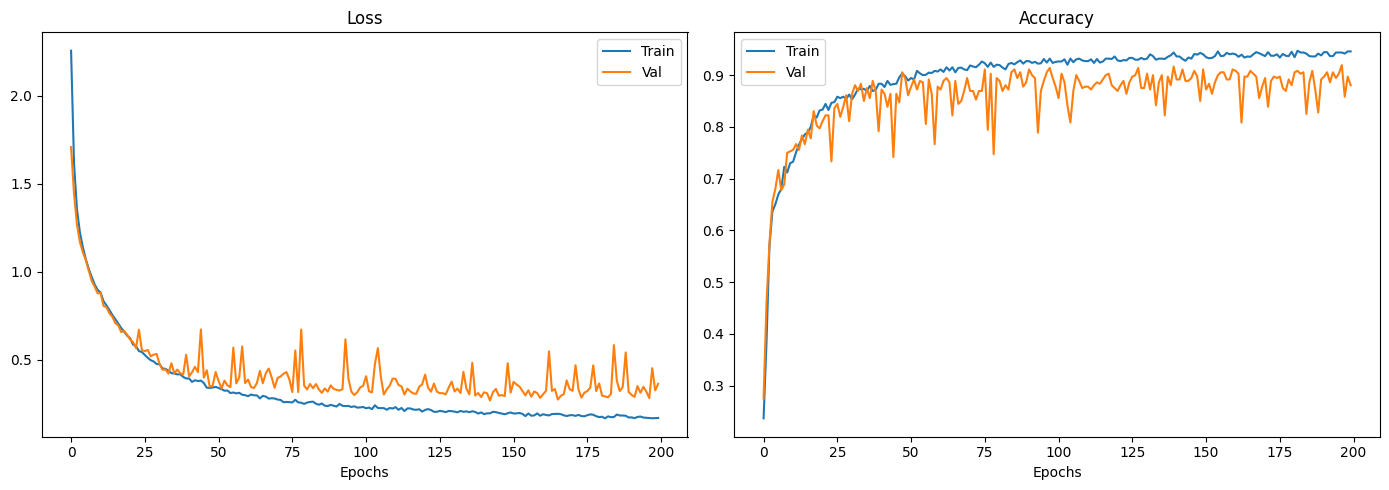


  OA    : 0.9133
  Kappa : 0.8853
  F1    : 0.9148
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      3401
           1       0.88      0.98      0.93       993
           2       0.91      0.81      0.86      1267
           3       0.68      0.87      0.76       727
           4       0.94      0.85      0.89       476
           5       0.88      0.87      0.87      1336

    accuracy                           0.91      8200
   macro avg       0.88      0.89      0.88      8200
weighted avg       0.92      0.91      0.91      8200



In [12]:
from sklearn.metrics import (confusion_matrix, cohen_kappa_score,
                             f1_score, accuracy_score, classification_report)# ============================================================
# 6. COURBES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['loss'],     label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epochs')
axes[0].legend()

axes[1].plot(history['accuracy'],     label='Train')
axes[1].plot(history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# 7. MÉTRIQUES SUR LE TEST
# ============================================================
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        out = model(X_batch)
        # Ensure outputs are CPU tensors before calling .argmax(1).numpy()
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(y_batch.cpu().numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

OA    = accuracy_score(all_true, all_preds)
Kappa = cohen_kappa_score(all_true, all_preds)
F1    = f1_score(all_true, all_preds, average='weighted')

print("\n" + "=" * 40)
print(f"  OA    : {OA:.4f}")
print(f"  Kappa : {Kappa:.4f}")
print(f"  F1    : {F1:.4f}")
print("=" * 40)
print(classification_report(all_true, all_preds))



In [ ]:
========================================
  OA    : 0.9354
  Kappa : 0.9225
  F1    : 0.9360
========================================
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       240
           1       0.98      0.98      0.98       240
           2       0.84      0.89      0.86       240
           3       0.85      0.87      0.86       240
           4       0.99      0.92      0.95       240
           5       0.97      0.97      0.97       240

    accuracy                           0.94      1440
   macro avg       0.94      0.94      0.94      1440
weighted avg       0.94      0.94      0.94      1440

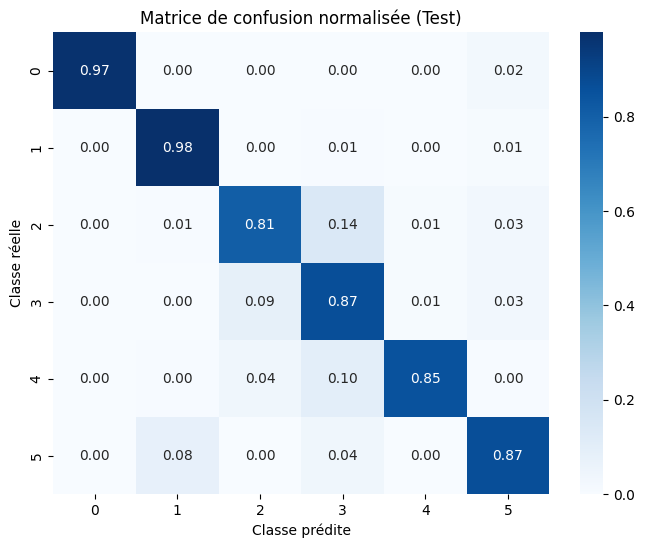

In [11]:
# ============================================================
# 8. MATRICE DE CONFUSION
# ============================================================
cm      = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1).reshape(-1, 1)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues')
plt.title('Matrice de confusion normalisée (Test)')
plt.xlabel('Classe prédite')
plt.ylabel('Classe réelle')
plt.show()
